In [ ]:
pip install prophet

In [2]:
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings, gc
warnings.filterwarnings('ignore')

In [3]:
sales=pd.read_feather("/kaggle/input/datasets/nevilmathewshelly/features-for-scaling/sales_features.feather")
sales['date']=pd.to_datetime(sales['date'])

In [4]:
sales

,item_id,store_id,dept_id,cat_id,state_id,sales,date,sell_price,snap_CA,lag_7,...,year,week_of_yr,is_weekend,quarter,has_event,event_type_enc,price_change,price_rel_mean,price_direction,event_name_enc
0,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,3,2011-01-29,2.00,0,NaN,...,2011,4,1,1,0,0,NaN,0.923653,0,0
1,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,0,2011-01-30,2.00,0,NaN,...,2011,4,1,1,0,0,0.0,0.923653,0,0
2,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,0,2011-01-31,2.00,0,NaN,...,2011,5,0,1,0,0,0.0,0.923653,0,0
3,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,1,2011-02-01,2.00,1,NaN,...,2011,5,0,1,0,0,0.0,0.923653,0,0
4,FOODS_1_001,CA_1,FOODS_1,FOODS,CA,4,2011-02-02,2.00,1,NaN,...,2011,5,0,1,0,0,0.0,0.923653,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
59181085,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-18,5.94,0,0.0,...,2016,20,0,2,0,0,0.0,1.000601,0,0
59181086,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-19,5.94,0,0.0,...,2016,20,0,2,0,0,0.0,1.000601,0,0
59181087,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-20,5.94,0,0.0,...,2016,20,0,2,0,0,0.0,1.000601,0,0
59181088,HOUSEHOLD_2_516,WI_3,HOUSEHOLD_2,HOUSEHOLD,WI,0,2016-05-21,5.94,0,1.0,...,2016,20,1,2,0,0,0.0,1.000601,0,0


In [5]:
mask=(
    (sales['store_id']=='CA_1')&
    (sales['dept_id']=='FOODS_1')
)
subset=sales[mask].copy()

top_items = (
    subset.groupby('item_id')['sales']
    .sum()
    .sort_values(ascending=False)
    .head(50)
    .index.tolist()
)

# Aggregate top 50 items to one series
top50 = subset[subset['item_id'].isin(top_items)].copy()

dept_daily = (
    top50.groupby('date')
    .agg(
        y         = ('sales',     'sum'),
        snap_CA   = ('snap_CA',   'max'),
        has_event = ('has_event', 'max')
    )
    .reset_index()
    .rename(columns={'date':'ds'})
)

print(f"Shape      : {dept_daily.shape}")
print(f"Avg daily  : {dept_daily['y'].mean():.1f} units")

Shape      : (1941, 4)
Avg daily  : 181.7 units


In [6]:
print(f"Items in scope : {subset['item_id'].nunique()}")
print(f"Date range     : {subset['date'].min().date()} → {subset['date'].max().date()}")
print(f"Rows           : {len(subset):,}")

Items in scope : 216
Date range     : 2011-01-29 → 2016-05-22
Rows           : 419,256


In [7]:
cutoff = dept_daily['ds'].max() - pd.Timedelta(days=28)

train_p = dept_daily[dept_daily['ds'] <= cutoff]
test_p  = dept_daily[dept_daily['ds'] >  cutoff]

print(f"Train : {train_p['ds'].min().date()} → {train_p['ds'].max().date()} ({len(train_p)} rows)")
print(f"Test  : {test_p['ds'].min().date()}  → {test_p['ds'].max().date()} ({len(test_p)} rows)")

Train : 2011-01-29 → 2016-04-24 (1913 rows)
Test  : 2016-04-25  → 2016-05-22 (28 rows)


In [8]:
gc.collect()

0

In [10]:
calendar=pd.read_csv("/kaggle/input/datasets/nevilmathewshelly/dates-features/calendar.csv")
calendar['ds']=pd.to_datetime(calendar['date'])


In [11]:
holidays_df = (
    calendar[calendar['event_name_1'].notna()]
    [['ds', 'event_name_1']]
    .drop_duplicates()
    .rename(columns={'event_name_1': 'holiday'})
    .assign(
        lower_window = -1,
        upper_window =  1
    )
)


In [12]:
# holidays_df=holidays_df.astype('str')
print(f"Holiday entries : {len(holidays_df)}")
print(holidays_df.head(10))

Holiday entries : 162
           ds         holiday  lower_window  upper_window
8  2011-02-06       SuperBowl            -1             1
16 2011-02-14   ValentinesDay            -1             1
23 2011-02-21   PresidentsDay            -1             1
39 2011-03-09       LentStart            -1             1
46 2011-03-16       LentWeek2            -1             1
47 2011-03-17   StPatricksDay            -1             1
50 2011-03-20       Purim End            -1             1
85 2011-04-24  OrthodoxEaster            -1             1
87 2011-04-26      Pesach End            -1             1
96 2011-05-05   Cinco De Mayo            -1             1


In [ ]:
# 1. Get the list of 50 items
top_items = subset.groupby('item_id')['sales'].sum().sort_values(ascending=False).head(50).index.tolist()

all_prophet_preds = []

# 2. Train a separate Prophet model for each item
print("Training 50 Prophet models...")
for item in top_items:
    item_df = subset[subset['item_id'] == item].copy()
    
    # Format for Prophet
    item_df = item_df[['date', 'sales', 'snap_CA']].rename(columns={'date': 'ds', 'sales': 'y'})
    
    train_p = item_df[item_df['ds'] <= cutoff]
    test_p  = item_df[item_df['ds'] > cutoff]
    
    m = Prophet(
        seasonality_mode='multiplicative',
        yearly_seasonality=True,
        weekly_seasonality=True,
        daily_seasonality=False,
        holidays=holidays_df
    )
    m.add_regressor('snap_CA')
    
    # Suppress verbose output
    m.fit(train_p)
    
    # Predict
    future = item_df[['ds', 'snap_CA']].copy()
    forecast = m.predict(future)
    
    # Extract just the 28-day test period
    test_forecast = forecast[forecast['ds'] > cutoff].copy()
    
    item_results = pd.DataFrame({
        'date': test_forecast['ds'],
        'item_id': item,
        'actual': test_p['y'].values,
        'prophet_pred': np.clip(test_forecast['yhat'].values, 0, None)
    })
    
    all_prophet_preds.append(item_results)

# 3. Combine and Save
prophet_item_level = pd.concat(all_prophet_preds, ignore_index=True)
prophet_item_level.sort_values(['item_id', 'date'], inplace=True)
prophet_item_level.reset_index(drop=True, inplace=True)

prophet_item_level.to_feather('prophet_item_level.feather')
prophet_item_level.to_csv('prophet_agg.csv', index=False)

print(f"Prophet Item-Level saved ✅ Shape: {prophet_item_level.shape}")

In [14]:
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

# 1. Calculate Global MAE and RMSE (across all 1,400 predictions)
mae_prophet = mean_absolute_error(prophet_item_level['actual'], prophet_item_level['prophet_pred'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_item_level['actual'], prophet_item_level['prophet_pred']))

# 2. Calculate Strict Item-Level MASE
mase_list = []

for item in top_items:
    # A. Get historical training data for this item to calculate the Naive Error denominator
    # (Relies on 'subset' and 'cutoff' still being in memory from your earlier cells)
    item_train = subset[(subset['item_id'] == item) & (subset['date'] <= cutoff)]['sales'].values
    naive_mae = np.mean(np.abs(np.diff(item_train)))
    
    # B. Get the test predictions and actuals for this item
    item_test = prophet_item_level[prophet_item_level['item_id'] == item]
    item_mae = mean_absolute_error(item_test['actual'], item_test['prophet_pred'])
    
    # C. Calculate MASE and append
    if naive_mae > 0:
        mase_list.append(item_mae / naive_mae)

mase_prophet = np.mean(mase_list)

# 3. Print the Final Report
print("=" * 40)
print("Prophet — 50-Item Forecast Evaluation")
print("=" * 40)
print(f"Global MAE  : {mae_prophet:.4f}")
print(f"Global RMSE : {rmse_prophet:.4f}")
print(f"Average MASE: {mase_prophet:.4f}")
print("=" * 40)

Prophet — 50-Item Forecast Evaluation
Global MAE  : 2.7006
Global RMSE : 4.0066
Average MASE: 1.1636


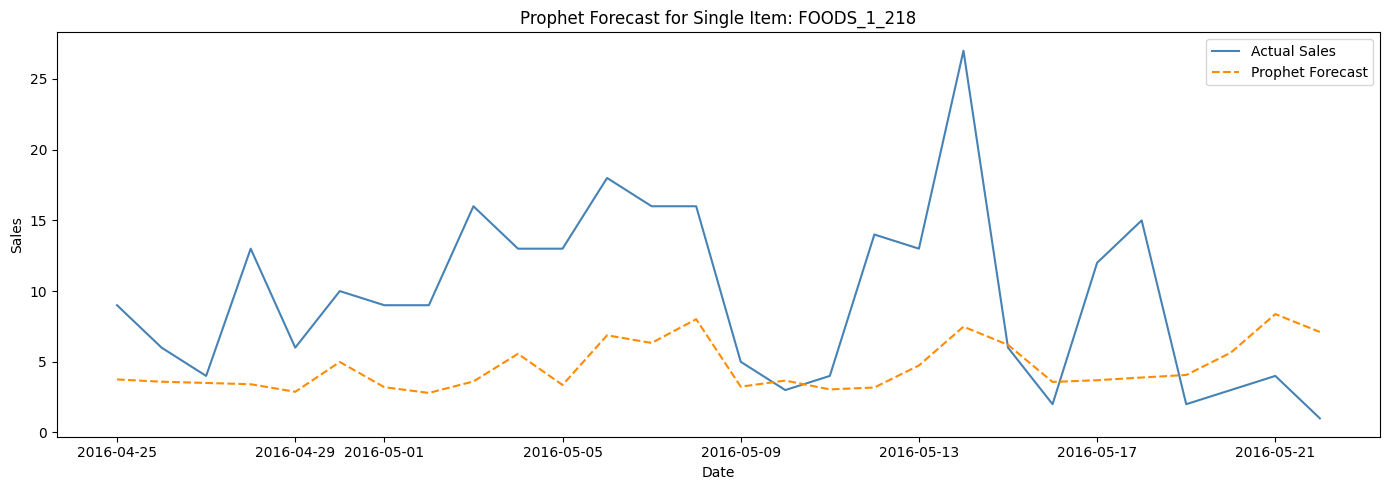

In [15]:
# Pick the highest volume item to visualize
sample_item = top_items[0] 

# Filter the dataframe for just that one item
single_item_df = prophet_item_level[prophet_item_level['item_id'] == sample_item]

plt.figure(figsize=(14, 5))
plt.plot(single_item_df['date'], single_item_df['actual'], label='Actual Sales', color='steelblue')
plt.plot(single_item_df['date'], single_item_df['prophet_pred'], label='Prophet Forecast', color='darkorange', linestyle='--')
plt.title(f'Prophet Forecast for Single Item: {sample_item}')
plt.xlabel('Date')
plt.ylabel('Sales')
plt.legend()
plt.tight_layout()
plt.show()